In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import statsmodels.api as sm

1. LOAD DATA

In [155]:
# Load
df = pd.read_csv("data_fix.csv")

# chuẩn hóa ts & sort
df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
df = df.sort_values(["symbol","ts"])

df.head()


,ts,open,high,low,close,adj_close,volume,symbol
0,2015-01-02 00:00:00+00:00,41.180000,41.310001,40.369999,40.560001,37.120949,1529200.0,A
1,2015-01-05 00:00:00+00:00,40.320000,40.459999,39.700001,39.799999,36.425385,2041800.0,A
2,2015-01-06 00:00:00+00:00,39.810001,40.020000,39.020000,39.180000,35.857960,2080600.0,A
3,2015-01-07 00:00:00+00:00,39.520000,39.810001,39.290001,39.700001,36.333866,3359700.0,A
4,2015-01-08 00:00:00+00:00,40.240002,40.980000,40.180000,40.889999,37.422966,2116300.0,A


In [156]:
# Tính log-return
df["return"] = (
    df.groupby("symbol", group_keys=False)["close"]
      .apply(lambda s: np.log(s / s.shift(1)))
)

df[["ts","symbol","close","return"]].head()


,ts,symbol,close,return
0,2015-01-02 00:00:00+00:00,A,40.560001,NaN
1,2015-01-05 00:00:00+00:00,A,39.799999,-0.018916
2,2015-01-06 00:00:00+00:00,A,39.180000,-0.015700
3,2015-01-07 00:00:00+00:00,A,39.700001,0.013185
4,2015-01-08 00:00:00+00:00,A,40.889999,0.029534


In [157]:
total_log_ret = df.groupby("symbol")["return"].sum()

# Quy đổi sang tổng simple return (tính từ log-return):
# total_simple_ret = exp(sum log_return) - 1
total_simple_ret = np.exp(total_log_ret) - 1

# Gộp lại thành 1 bảng
total_ret_df = pd.DataFrame({
    "total_log_return": total_log_ret,
    "total_simple_return": total_simple_ret
}).reset_index()

# Sắp xếp symbol có performance cao nhất
total_ret_df = total_ret_df.sort_values("total_simple_return", ascending=False)

print("Tổng return theo từng symbol (tính từ data_fix):")
print(total_ret_df.head(20)) 

Tổng return theo từng symbol (tính từ data_fix):
    symbol  total_log_return  total_simple_return
643   NVDA          5.915528           369.750126
163   CELH          5.843369           343.939321
50     AMD          4.104221            59.595501
839   STRL          3.970145            51.992200
455   IESC          3.953484            51.116643
361    FIX          3.889472            47.885073
60    ANET          3.616165            36.194641
240   CVNA          3.525936            32.985584
87    AVGO          3.495335            31.961336
884   TSLA          3.415009            29.417216
92    AXON          3.298446            26.070540
208   CORT          3.282332            25.637822
333   EXEL          3.220087            24.030303
625   NFLX          3.180187            23.051242
874    TPL          3.167019            22.736611
801   SITM          3.143190            22.177692
504   KNSL          3.143071            22.174932
244   CWST          3.136760            22.029126
9

In [158]:
def detect_return_outliers(df):
    out_list = []
    
    for sym, g in df.groupby("symbol"):
        r = g["return"].dropna()
        if r.empty:
            continue
        
        # IQR
        q1 = r.quantile(0.25)
        q3 = r.quantile(0.75)
        iqr = q3 - q1
        lb = q1 - 1.5*iqr
        ub = q3 + 1.5*iqr
        
        # mask outlier
        mask = (g["return"] < lb) | (g["return"] > ub)
        outliers = g.loc[mask, ["ts","symbol","close","return"]]
        
        if not outliers.empty:
            out_list.append(outliers)
    
    if out_list:
        return pd.concat(out_list).sort_values(["symbol","ts"])
    return pd.DataFrame(columns=["ts","symbol","close","return"])


In [159]:
outliers_df = detect_return_outliers(df)

print("Tổng số outlier:", len(outliers_df))
print("Số symbol có outlier:", outliers_df["symbol"].nunique())
print("\n20 dòng đầu tiên:")
print(outliers_df.head(20))


Tổng số outlier: 120957
Số symbol có outlier: 992

20 dòng đầu tiên:
                           ts symbol      close    return
13  2015-01-22 00:00:00+00:00      A  39.650002  0.038303
161 2015-08-24 00:00:00+00:00      A  34.680000 -0.043724
167 2015-09-01 00:00:00+00:00      A  34.750000 -0.043914
255 2016-01-07 00:00:00+00:00      A  39.000000 -0.043403
259 2016-01-13 00:00:00+00:00      A  36.860001 -0.035447
270 2016-01-29 00:00:00+00:00      A  37.650002  0.041763
275 2016-02-05 00:00:00+00:00      A  36.040001 -0.037576
276 2016-02-08 00:00:00+00:00      A  34.799999 -0.035012
372 2016-06-24 00:00:00+00:00      A  44.119999 -0.056403
373 2016-06-27 00:00:00+00:00      A  42.259998 -0.043072
410 2016-08-18 00:00:00+00:00      A  46.720001 -0.035947
425 2016-09-09 00:00:00+00:00      A  44.880001 -0.046581
447 2016-10-11 00:00:00+00:00      A  45.689999 -0.042842
457 2016-10-25 00:00:00+00:00      A  43.509998 -0.052384
601 2017-05-23 00:00:00+00:00      A  58.660000  0.044979
660

In [160]:
def winsorize_return(df):
    df = df.copy()
    df["return_clean"] = np.nan
    
    for sym, g in df.groupby("symbol"):
        r = g["return"]
        if r.isna().all():
            continue
        
        lo = r.quantile(0.01)
        hi = r.quantile(0.99)
        
        df.loc[g.index, "return_clean"] = r.clip(lo, hi)
    
    return df

df_clean = winsorize_return(df)

df_clean[["ts","symbol","return","return_clean"]].head()


,ts,symbol,return,return_clean
0,2015-01-02 00:00:00+00:00,A,NaN,NaN
1,2015-01-05 00:00:00+00:00,A,-0.018916,-0.018916
2,2015-01-06 00:00:00+00:00,A,-0.015700,-0.015700
3,2015-01-07 00:00:00+00:00,A,0.013185,0.013185
4,2015-01-08 00:00:00+00:00,A,0.029534,0.029534


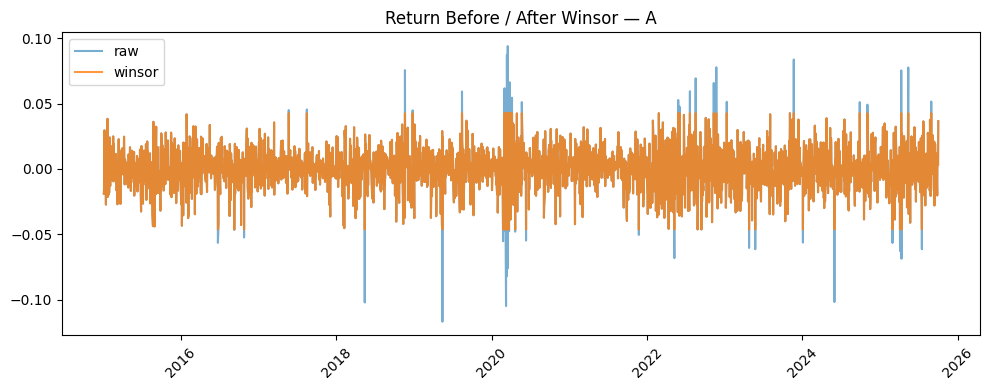

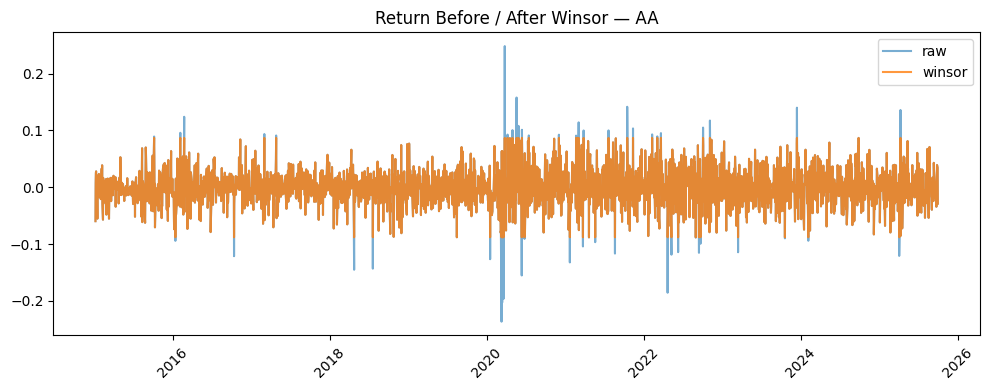

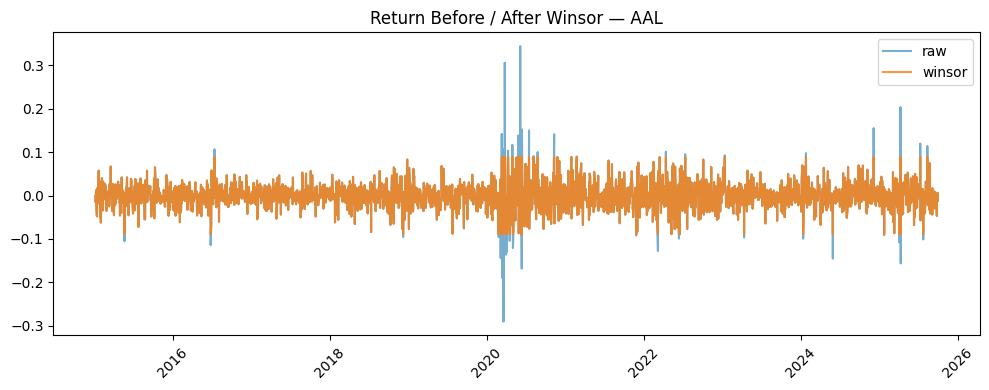

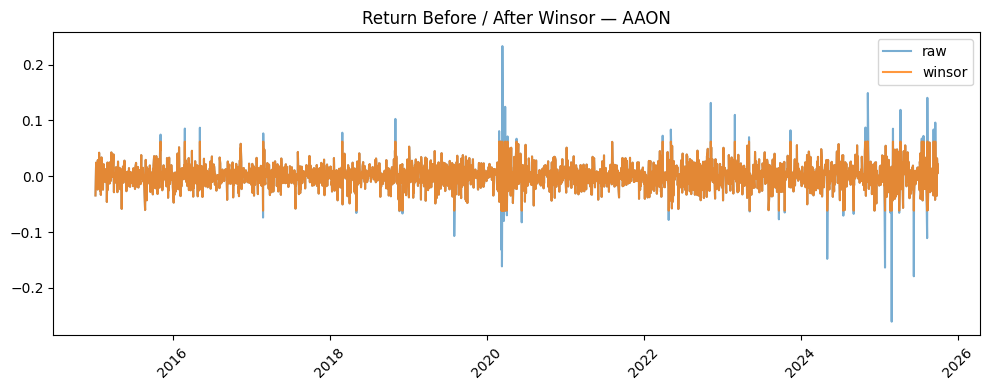

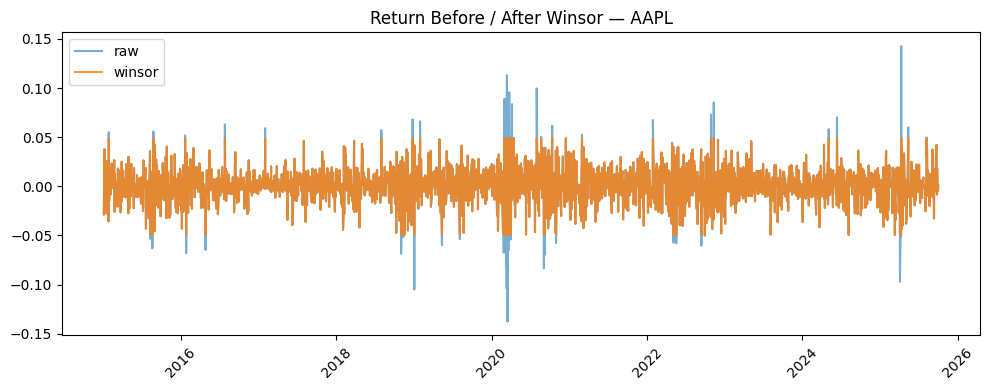

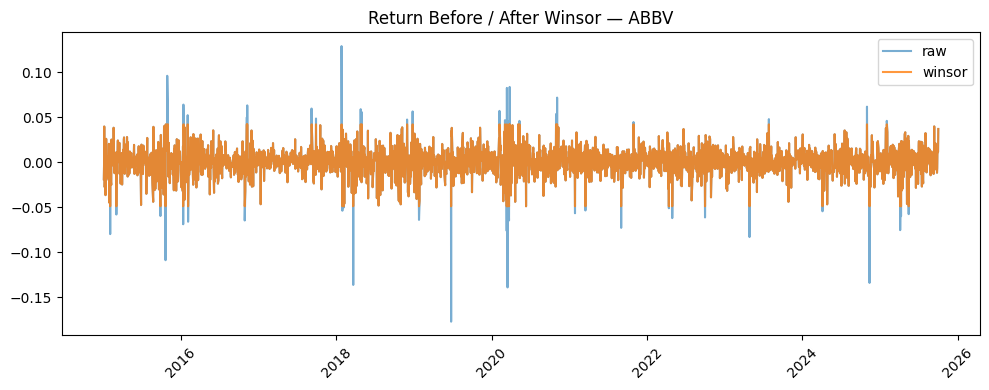

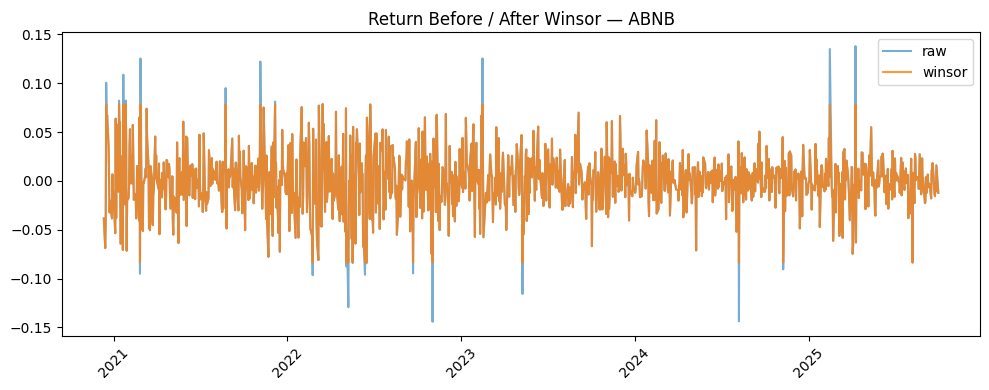

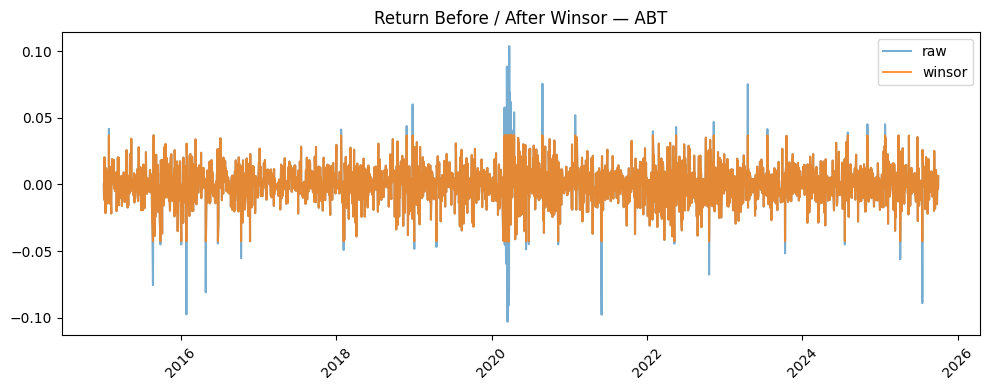

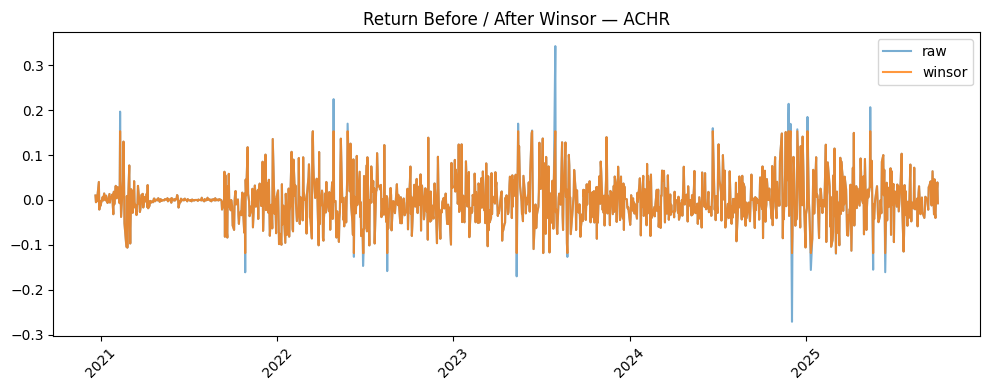

In [161]:
symbols = df["symbol"].unique()

for sym in symbols[:9]:
    g = df[df["symbol"]==sym].copy()
    gc = df_clean[df_clean["symbol"]==sym].copy()

    plt.figure(figsize=(10,4))
    
    plt.plot(g["ts"], g["return"], label="raw", alpha=0.6)
    plt.plot(gc["ts"], gc["return_clean"], label="winsor", alpha=0.8)
    
    plt.title(f"Return Before / After Winsor — {sym}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [162]:
# 5. Lưu thành file mới
df_clean.to_csv("data_fix_clean.csv", index=False)
print("Đã lưu file: data_fix_clean.csv")


Đã lưu file: data_fix_clean.csv


In [163]:
# Chọn ngẫu nhiên 3 symbol có return_clean đầy đủ
valid_symbols = df_clean[df_clean["return_clean"].notna()]["symbol"].unique()
symbols = np.random.choice(valid_symbols, size=3, replace=False)

print("3 cổ phiếu được chọn:", symbols)

regression_results = []

for sym in symbols:
    print("\n==============================")
    print("REGRESSION FOR:", sym)
    print("==============================")

    g = df_clean[df_clean["symbol"] == sym].copy()

    # Tạo lag-1
    g["lag_clean"] = g["return_clean"].shift(1)

    # Tạo reg dataset
    reg = g.dropna(subset=["return_clean", "lag_clean"])

    if len(reg) < 50:
        print("Không đủ dữ liệu, bỏ qua.")
        continue

    # Regression: r_t = α + β r_{t-1}
    X = sm.add_constant(reg["lag_clean"])
    y = reg["return_clean"]

    model = sm.OLS(y, X).fit()

    # In bảng hệ số
    print(model.summary().tables[1])

    # Lưu lại kết quả để so sánh
    regression_results.append((sym, model))


3 cổ phiếu được chọn: ['IBP' 'CRL' 'PANW']

REGRESSION FOR: IBP
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.001      2.101      0.036     7.3e-05       0.002
lag_clean     -0.0356      0.019     -1.849      0.065      -0.073       0.002

REGRESSION FOR: CRL
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.251      0.211      -0.000       0.001
lag_clean      0.0059      0.019      0.306      0.760      -0.032       0.044

REGRESSION FOR: PANW
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.336      0.020       0.000       0.002
lag_clean     -0.0038   

In [164]:
print("\n========== DIRECTIONAL ACCURACY ==========\n")

for sym, model in regression_results:
    # Lấy lại dữ liệu symbol
    g = df_clean[df_clean["symbol"] == sym].copy()
    g["lag_clean"] = g["return_clean"].shift(1)

    reg = g.dropna(subset=["return_clean","lag_clean"])

    X = sm.add_constant(reg["lag_clean"])
    y_true = reg["return_clean"].values
    y_pred = model.predict(X).values

    # Direction accuracy: so sánh dấu
    sign_true = np.sign(y_true)
    sign_pred = np.sign(y_pred)

    mask = (sign_true != 0) & (sign_pred != 0)
    DA = (sign_true[mask] == sign_pred[mask]).mean()

    print(f"Symbol: {sym}")
    print(f"Directional Accuracy: {DA*100:.2f}%")
    print("------------------------------------------")



========== DIRECTIONAL ACCURACY ==========

Symbol: IBP
Directional Accuracy: 52.47%
------------------------------------------
Symbol: CRL
Directional Accuracy: 52.49%
------------------------------------------
Symbol: PANW
Directional Accuracy: 53.80%
------------------------------------------


Improve regression

In [165]:
df_mom = df_clean.copy()


In [166]:
# 20-day momentum: log(P_t / P_{t-20}) theo từng symbol
df_mom["mom_20"] = (
    df_mom.groupby("symbol")["close"]
          .transform(lambda s: np.log(s / s.shift(20)))
)

# future_ret = return_clean ngày t+1 (shift -1) theo từng symbol
df_mom["future_ret"] = (
    df_mom.groupby("symbol")["return_clean"]
          .transform(lambda s: s.shift(-1))
)

# Bỏ những dòng không đủ dữ liệu
df_mom = df_mom.dropna(subset=["mom_20", "future_ret"])

df_mom[["ts", "symbol", "mom_20", "future_ret"]].head()


,ts,symbol,mom_20,future_ret
20,2015-02-02 00:00:00+00:00,A,-0.047201,0.023753
21,2015-02-03 00:00:00+00:00,A,-0.004533,-0.012956
22,2015-02-04 00:00:00+00:00,A,-0.001788,0.010682
23,2015-02-05 00:00:00+00:00,A,-0.004291,-0.004818
24,2015-02-06 00:00:00+00:00,A,-0.038644,-0.007655


In [167]:
valid_symbols = df_mom["symbol"].unique()
symbols = np.random.choice(valid_symbols, 3, replace=False)
print("3 cổ phiếu:", symbols)

results = []

for sym in symbols:
    print("\n==============================")
    print("SYMBOL:", sym)
    print("==============================")

    g = df_mom[df_mom["symbol"] == sym].copy()
    reg = g.dropna(subset=["mom_20", "future_ret"])
    if len(reg) < 50:
        print("Không đủ dữ liệu, bỏ qua.")
        continue

    X = sm.add_constant(reg["mom_20"])
    y = reg["future_ret"]

    model = sm.OLS(y, X).fit()
    print(model.summary().tables[1])

    # Directional Accuracy
    y_true = y.values
    y_pred = model.predict(X).values

    sign_true = np.sign(y_true)
    sign_pred = np.sign(y_pred)
    mask = (sign_true != 0) & (sign_pred != 0)
    DA = (sign_true[mask] == sign_pred[mask]).mean()

    print(f"Directional Accuracy: {DA*100:.2f}%")

    results.append({
        "symbol": sym,
        "beta_mom": model.params["mom_20"],
        "p_value": model.pvalues["mom_20"],
        "R2": model.rsquared,
        "DA": DA
    })


3 cổ phiếu: ['NYT' 'SYM' 'AFRM']

SYMBOL: NYT
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.861      0.063   -3.25e-05       0.001
mom_20        -0.0004      0.004     -0.099      0.921      -0.008       0.007
Directional Accuracy: 52.50%

SYMBOL: SYM
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      1.040      0.299      -0.001       0.004
mom_20        -0.0095      0.007     -1.434      0.152      -0.022       0.003
Directional Accuracy: 51.04%

SYMBOL: AFRM
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.002     -0.455      0.649      -0.004       0.003
